<a href="https://colab.research.google.com/github/anhtin18/SGU26_Ml/blob/main/cuoiky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install xgboost lightgbm catboost umap-learn

In [16]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [17]:
from google.colab import files

uploaded = files.upload()

Saving test.csv.zip to test.csv (1).zip
Saving train .csv.zip to train .csv (1).zip


In [18]:
import zipfile
import io

# Unzip uploaded files
for fn in uploaded.keys():
    if fn.endswith('.zip'): # Process only zip files
        print(f'Extracting files from "{fn}"...')
        with zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r') as zf:
            zf.extractall('/content/') # Extract to the /content/ directory
            print(f"Extracted: {', '.join(zf.namelist())}") # List the extracted files for confirmation

# Read the extracted CSV files using their confirmed names
train_df = pd.read_csv('/content/train (1).csv')
test_df = pd.read_csv('/content/test (2).csv')

train_df.head()

Extracting files from "test.csv (1).zip"...
Extracted: test (2).csv
Extracting files from "train .csv (1).zip"...
Extracted: train (1).csv


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


In [60]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=train_df)

https://docs.google.com/spreadsheets/d/1PpWd8iVjdqKwR_Z1u12Pyg_VCT_u91t96bGFzF598t4/edit#gid=0


In [19]:
print(train_df.shape)

train_df.info()

(14396, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float

In [62]:
train_df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,1.439600e+04,14396.000000,14396.000000
mean,7198.500000,44.513059,0.543105,0.662422,5.958947,-7.900852,0.640247,0.080181,0.246746,0.135278,0.195782,0.486379,122.695372,2.000942e+05,3.924354,6.695679
std,4155.911573,17.216466,0.165517,0.235967,3.015909,4.057362,0.479944,0.085157,0.310922,0.274652,0.159258,0.239476,29.538490,1.116891e+05,0.359520,3.206170
min,1.000000,1.000000,0.059600,0.001210,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.021500,30.557000,5.016500e-01,1.000000,0.000000
25%,3599.750000,33.000000,0.432000,0.508000,4.000000,-9.538000,0.000000,0.034800,0.004280,0.000295,0.097275,0.299000,99.799000,1.654458e+05,4.000000,5.000000
50%,7198.500000,44.000000,0.545000,0.699000,6.000000,-7.013500,1.000000,0.047100,0.081450,0.003920,0.129000,0.480500,120.060000,2.089410e+05,4.000000,8.000000
75%,10797.250000,56.000000,0.658000,0.861000,8.000000,-5.162000,1.000000,0.083100,0.432250,0.057600,0.256000,0.672000,141.988250,2.522470e+05,4.000000,10.000000
max,14396.000000,100.000000,0.989000,1.000000,11.000000,1.342000,1.000000,0.955000,0.996000,0.996000,0.992000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


In [20]:
train_df.isnull().sum()

,0
Id,0
Artist Name,0
Track Name,0
Popularity,333
danceability,0
energy,0
key,1609
loudness,0
mode,0
speechiness,0


In [25]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

In [22]:
train_df = train_df.drop_duplicates()

print(train_df.shape)

(14396, 18)


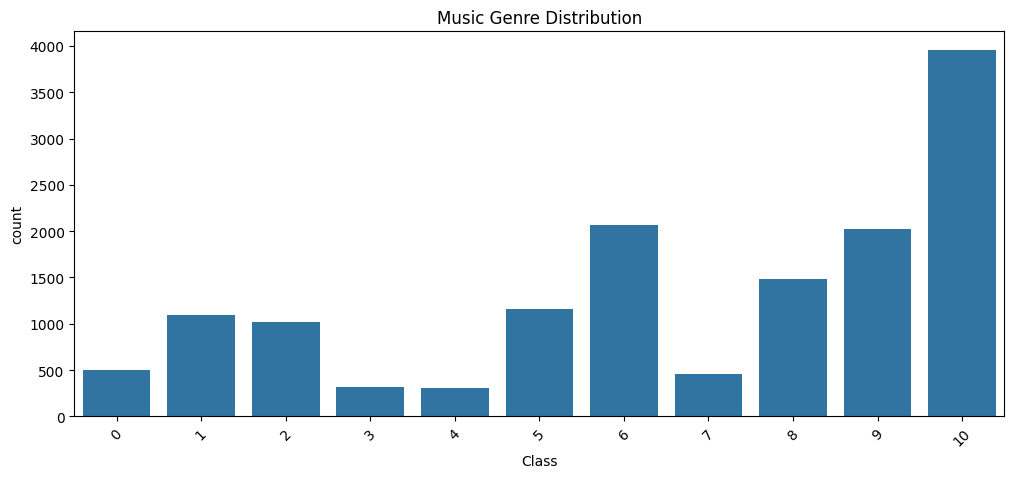

In [26]:
plt.figure(figsize=(12,5))

sns.countplot(x=train_df['Class'])

plt.xticks(rotation=45)

plt.title('Music Genre Distribution')

plt.show()

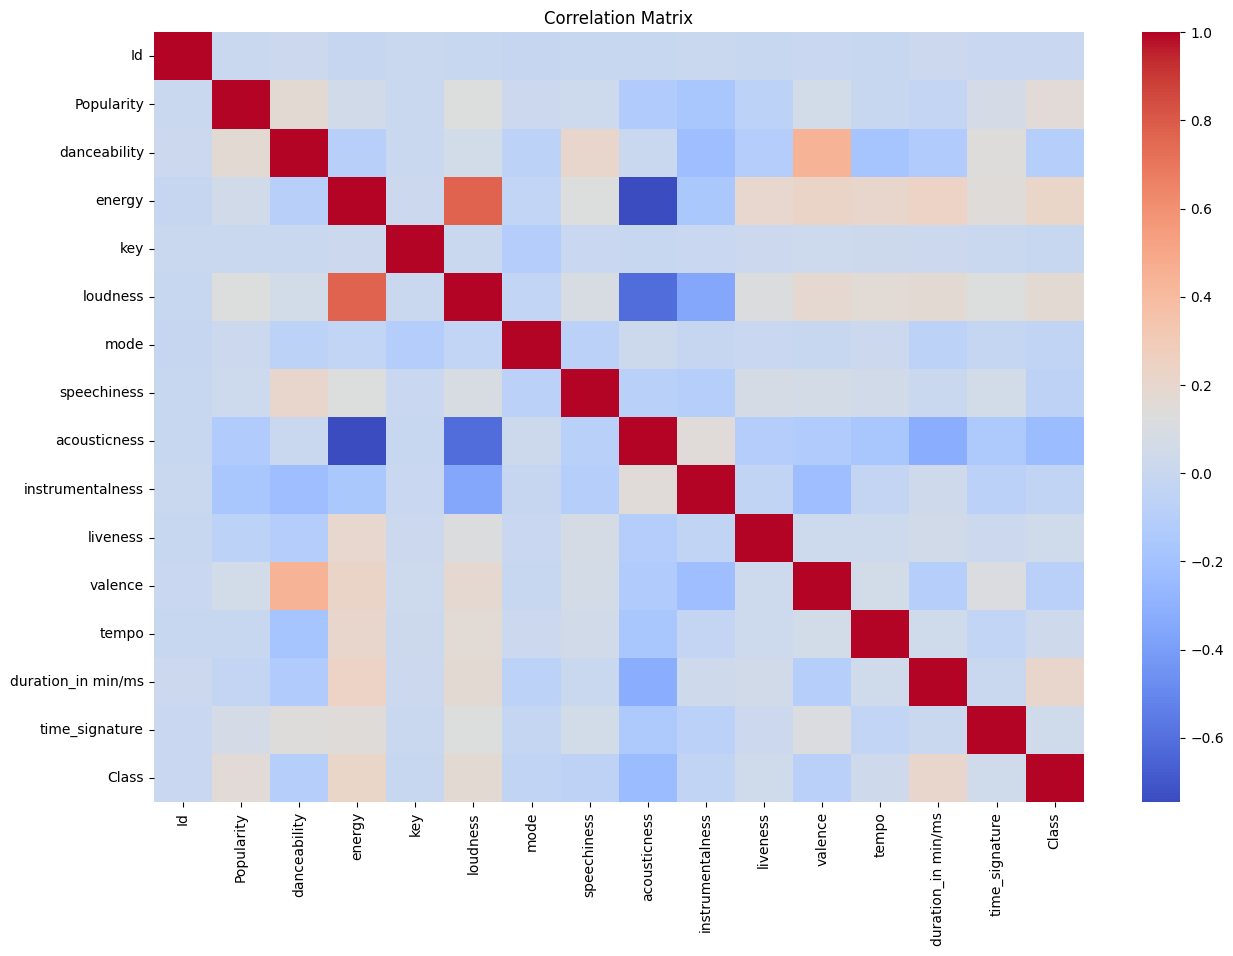

In [27]:
plt.figure(figsize=(15,10))

sns.heatmap(
    train_df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

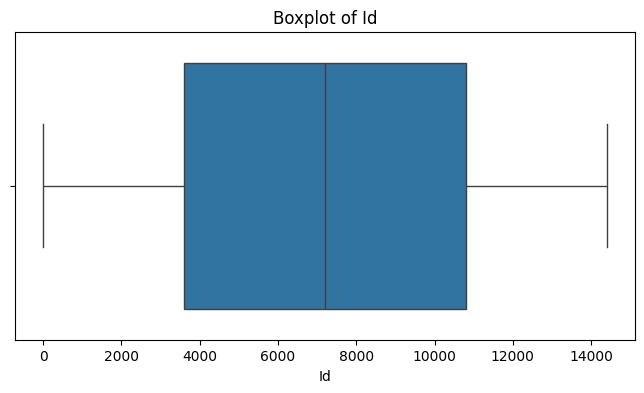

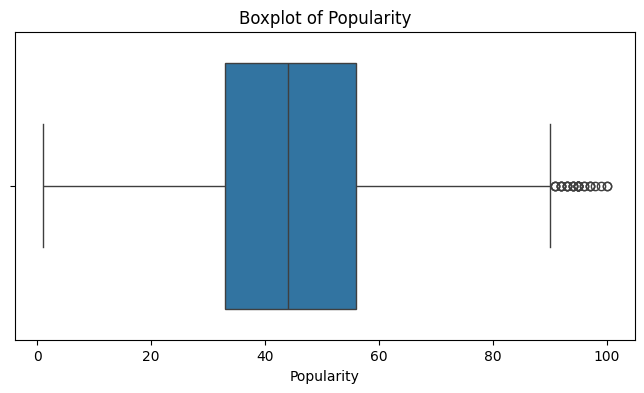

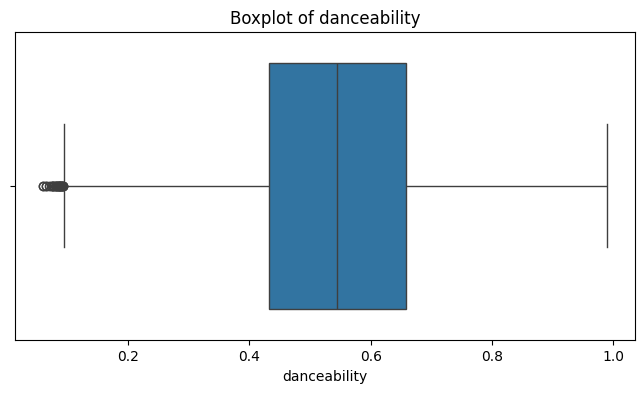

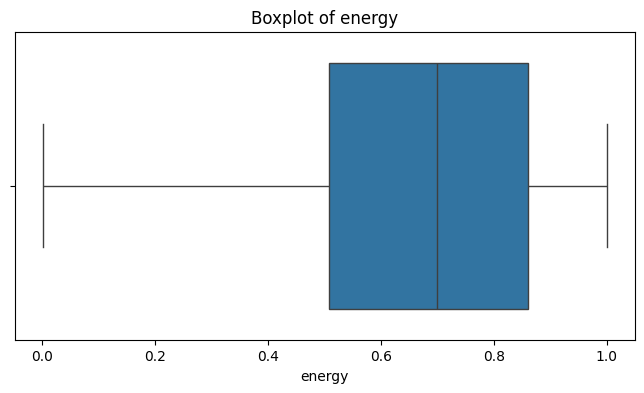

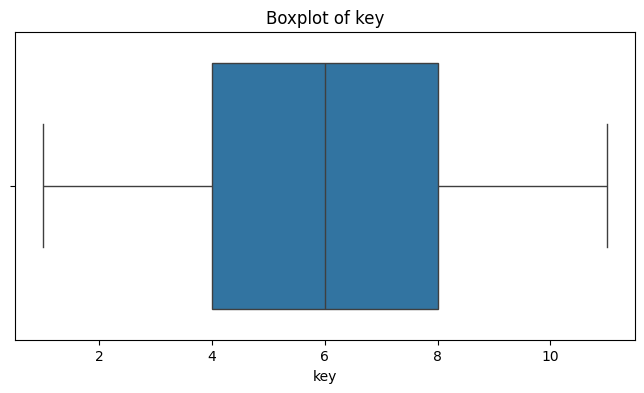

In [65]:
numeric_cols = train_df.select_dtypes(
    include=['int64','float64']
).columns

for col in numeric_cols[:5]:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=train_df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

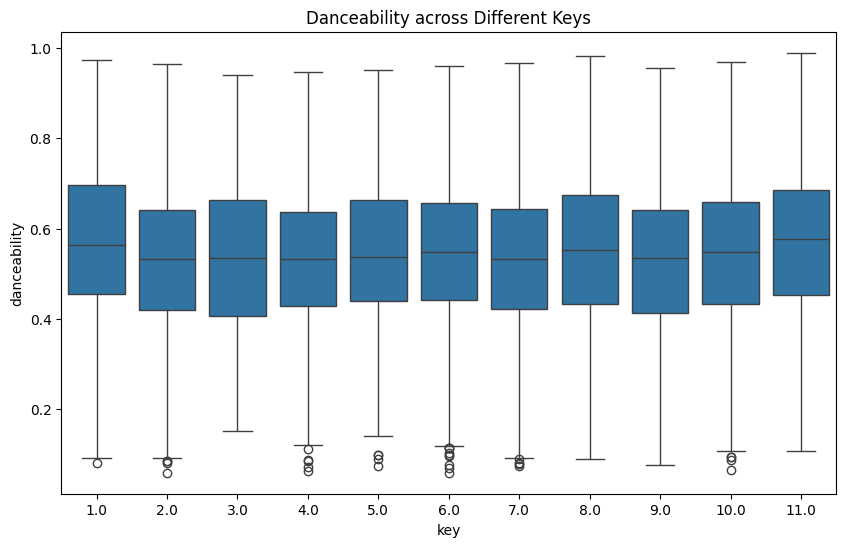

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=train_df,
    x='key',
    y='danceability'
)

plt.title('Danceability across Different Keys')

plt.show()

### Nhận xét

- Mức độ Danceability gần như không thay đổi đáng kể giữa các khóa nhạc (Key) khác nhau.
- Phân bố Danceability ở các Key khá tương đồng.
- Điều này cho thấy khóa nhạc không ảnh hưởng mạnh đến khả năng nhảy múa của bài hát.

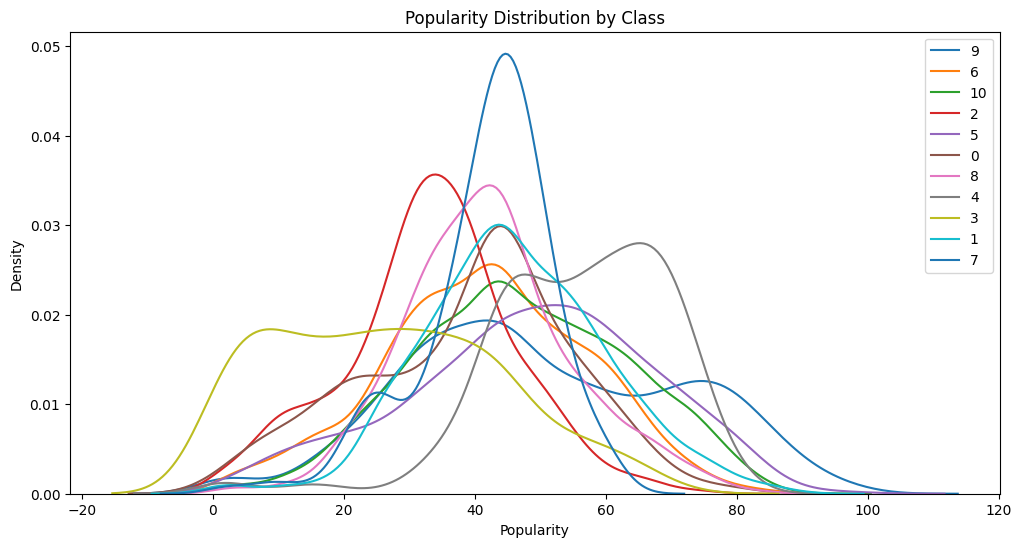

In [78]:
plt.figure(figsize=(12,6))

for genre in train_df['Class'].unique():

    subset = train_df[
        train_df['Class'] == genre
    ]

    sns.kdeplot(
        subset['Popularity'],
        label=genre,
        fill=False
    )

plt.title('Popularity Distribution by Class')

plt.xlabel('Popularity')

plt.ylabel('Density')

plt.legend()

plt.show()

### Nhận xét

- Đặc trưng `popularity` cho thấy mức độ chồng lấn dữ liệu rất lớn giữa các lớp.
- Phân bố của các thể loại nhạc gần như giao nhau mạnh.
- Điều này cho thấy độ nổi tiếng của bài hát không có quy luật rõ ràng theo thể loại nhạc.
- Vì vậy, `popularity` có thể là đặc trưng phân loại kém và gây nhiễu cho mô hình.

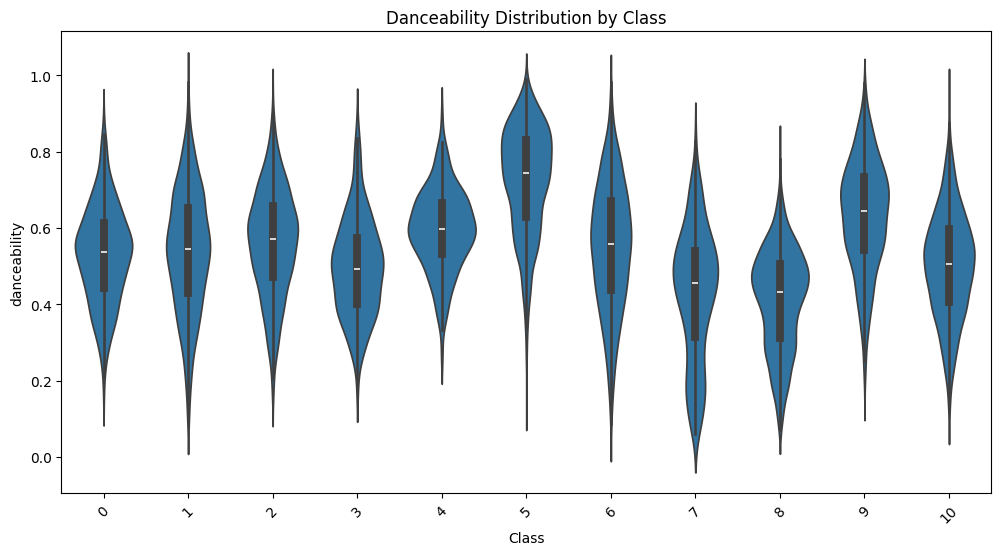

In [79]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=train_df,
    x='Class',
    y='danceability'
)

plt.xticks(rotation=45)

plt.title('Danceability Distribution by Class')

plt.show()

### Nhận xét

- Đặc trưng `danceability` có mức độ chồng lấn trung bình giữa các lớp.
- Một số thể loại có xu hướng phân bố khác nhau, tuy nhiên vẫn tồn tại vùng giao nhau đáng kể.
- Điều này cho thấy `danceability` có khả năng hỗ trợ phân loại nhưng chưa đủ mạnh để tách biệt hoàn toàn các thể loại nhạc.

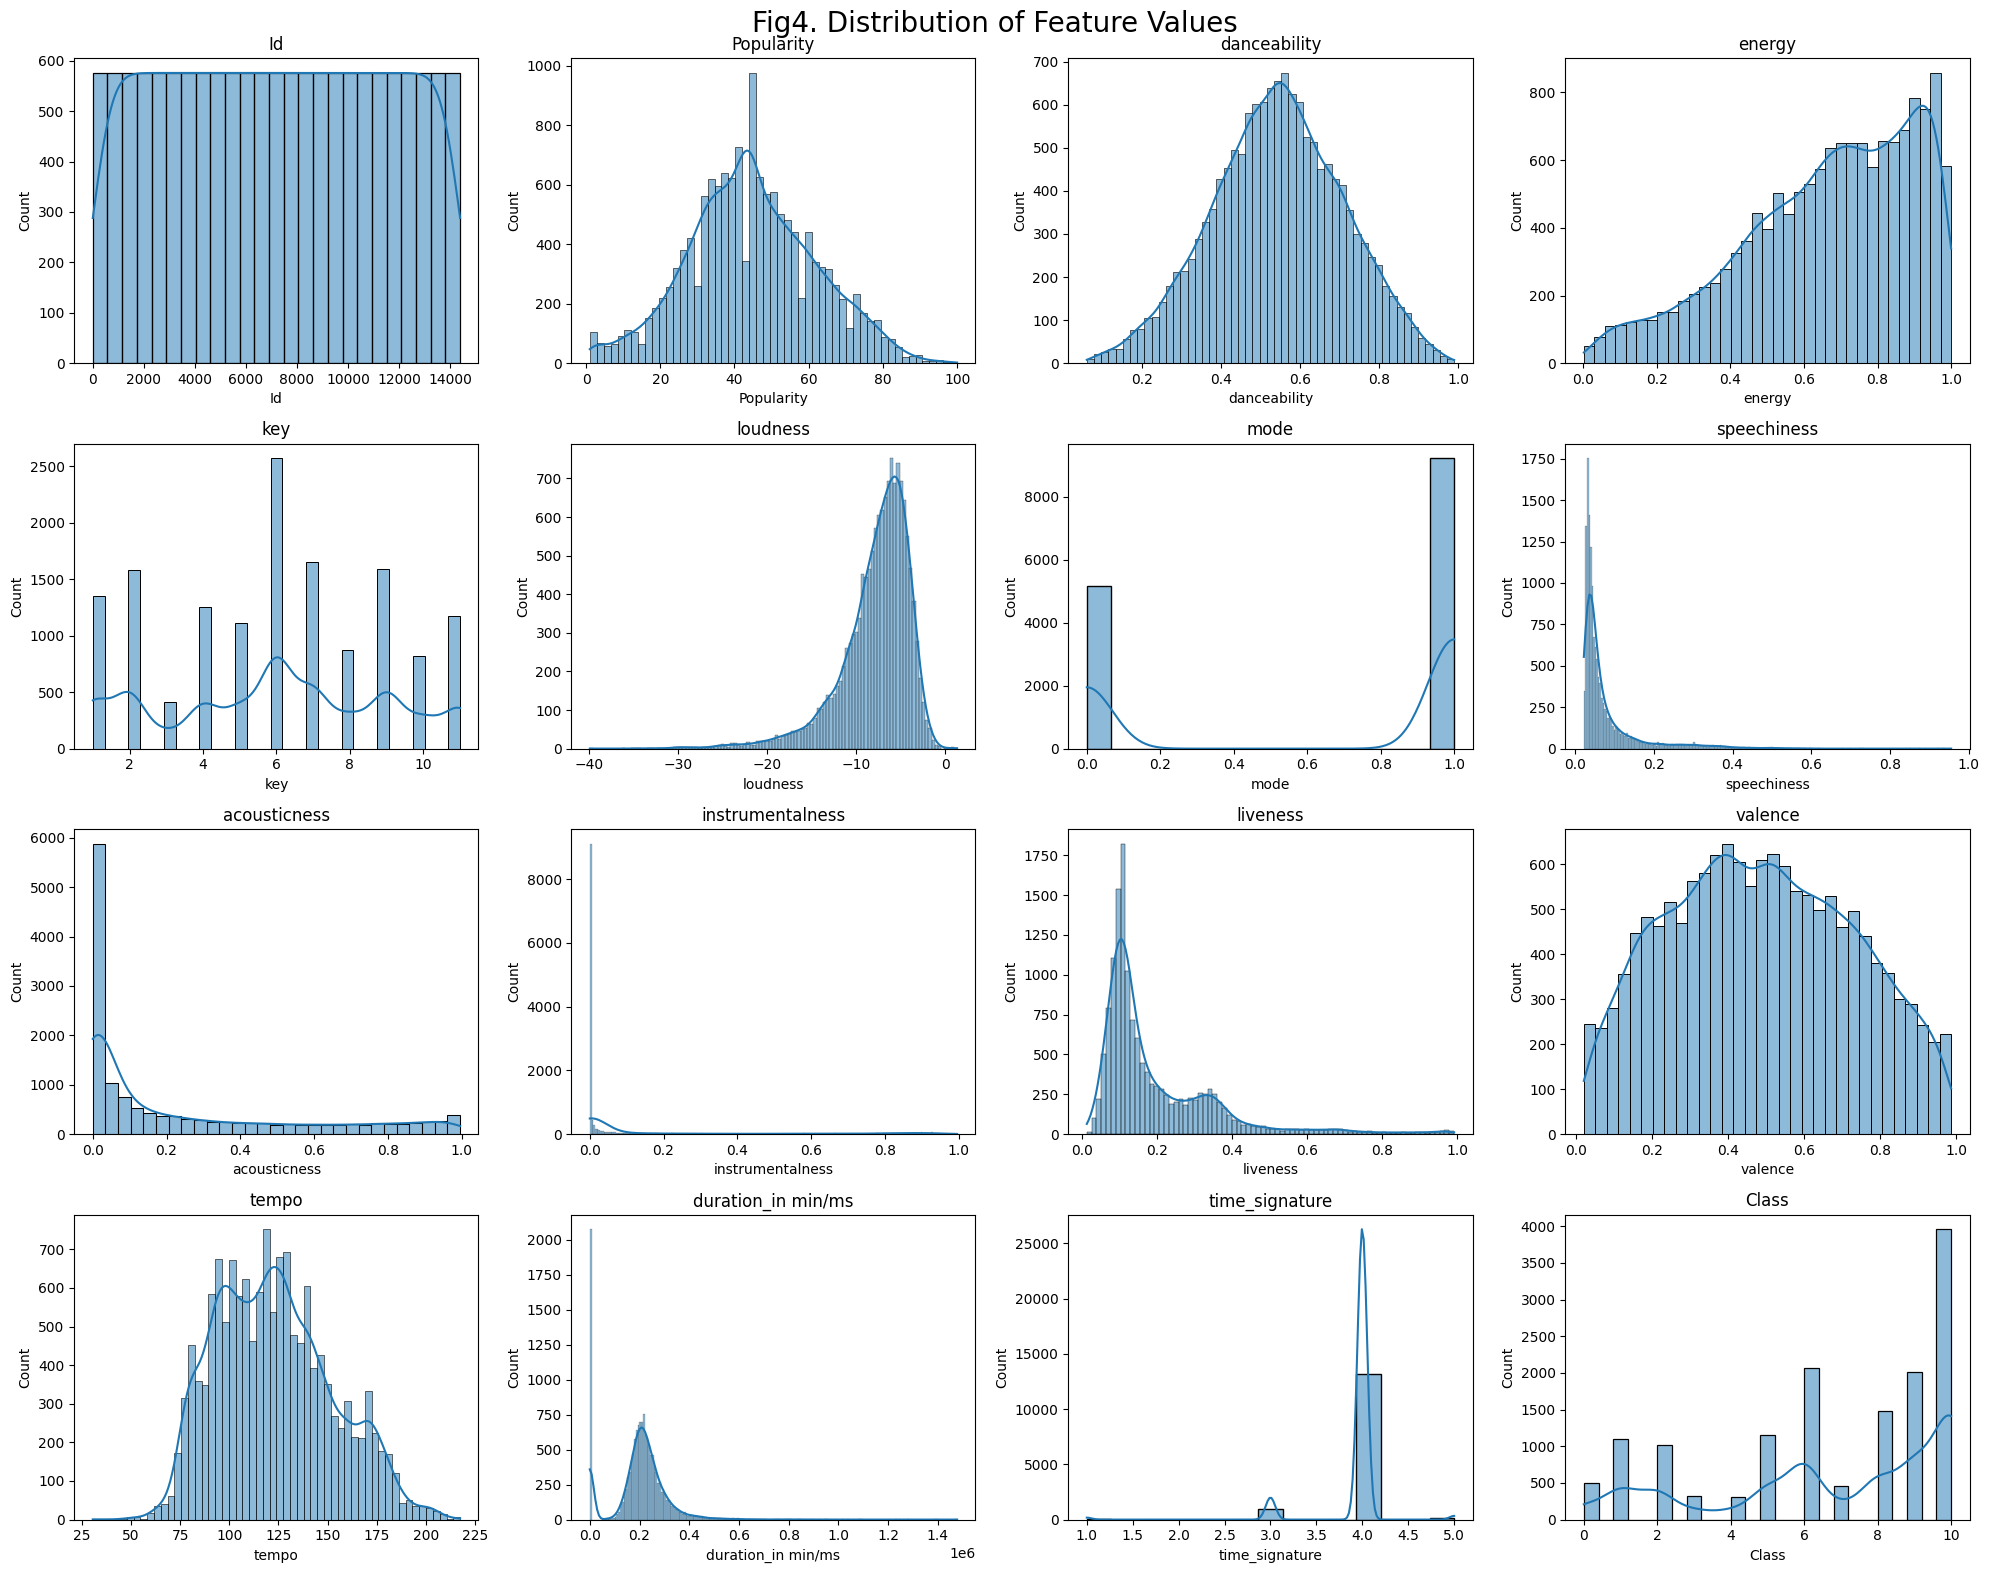

In [81]:
numeric_cols = train_df.select_dtypes(
    include=['int64', 'float64']
).columns

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(20,16)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols[:16]):

    sns.histplot(
        train_df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.suptitle(
    'Fig4. Distribution of Feature Values',
    fontsize=20
)

plt.tight_layout()

plt.show()

### Nhận xét

- Các đặc trưng trong bộ dữ liệu có phân bố khác nhau.
- Một số thuộc tính có phân bố gần chuẩn, trong khi một số khác bị lệch hoặc có nhiều outlier.
- Điều này cho thấy cần chuẩn hóa dữ liệu trước khi huấn luyện mô hình Machine Learning.

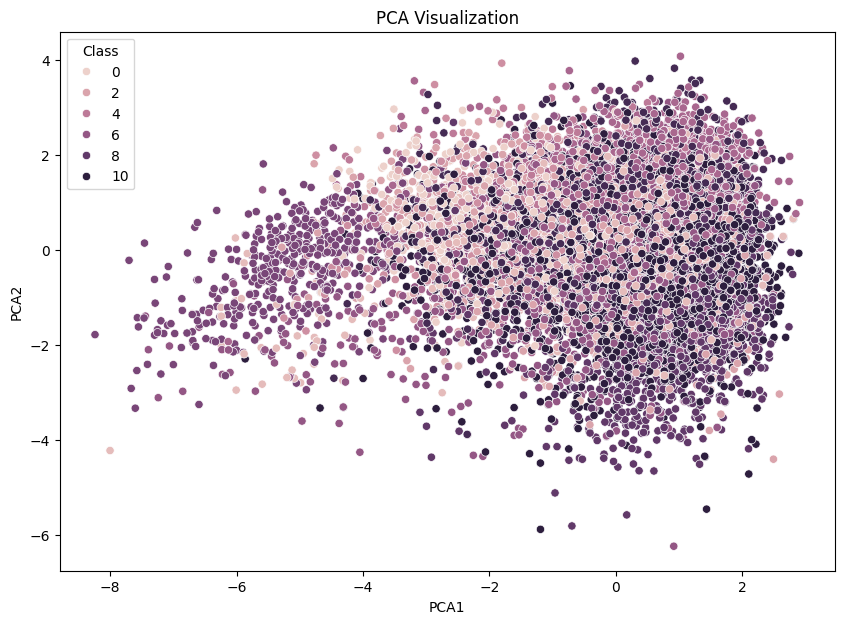

In [68]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_temp = train_df.drop(columns=['Class', 'Artist Name', 'Track Name']) # Drop non-numeric columns

y_temp = train_df['Class']

scaler_temp = StandardScaler()

X_scaled_temp = scaler_temp.fit_transform(X_temp)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled_temp)

pca_df = pd.DataFrame({
    'PCA1': X_pca[:,0],
    'PCA2': X_pca[:,1],
    'Class': y_temp
})

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Class'
)

plt.title('PCA Visualization')

plt.show()

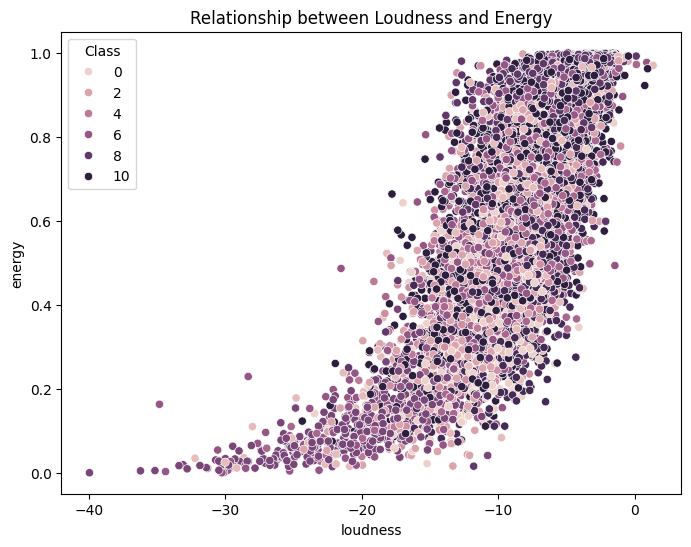

In [ ]:

sns.scatterplot(
    data=train_df,
    x='loudness',
    y='energy',
    hue='Class'
)

plt.title('Relationship between Loudness and Energy')

plt.show()

In [74]:
print("""
Nhận xét:

Loudness có mối quan hệ tương quan dương trực tiếp với Energy.

Các bản nhạc có độ lớn âm thanh (Loudness) cao thường có mức năng lượng (Energy) cao hơn.

Điều này cho thấy các bài nhạc sôi động và mạnh mẽ thường có âm lượng lớn hơn so với các bài nhạc nhẹ nhàng.
""")


Nhận xét:

Loudness có mối quan hệ tương quan dương trực tiếp với Energy.

Các bản nhạc có độ lớn âm thanh (Loudness) cao thường có mức năng lượng (Energy) cao hơn.

Điều này cho thấy các bài nhạc sôi động và mạnh mẽ thường có âm lượng lớn hơn so với các bài nhạc nhẹ nhàng.



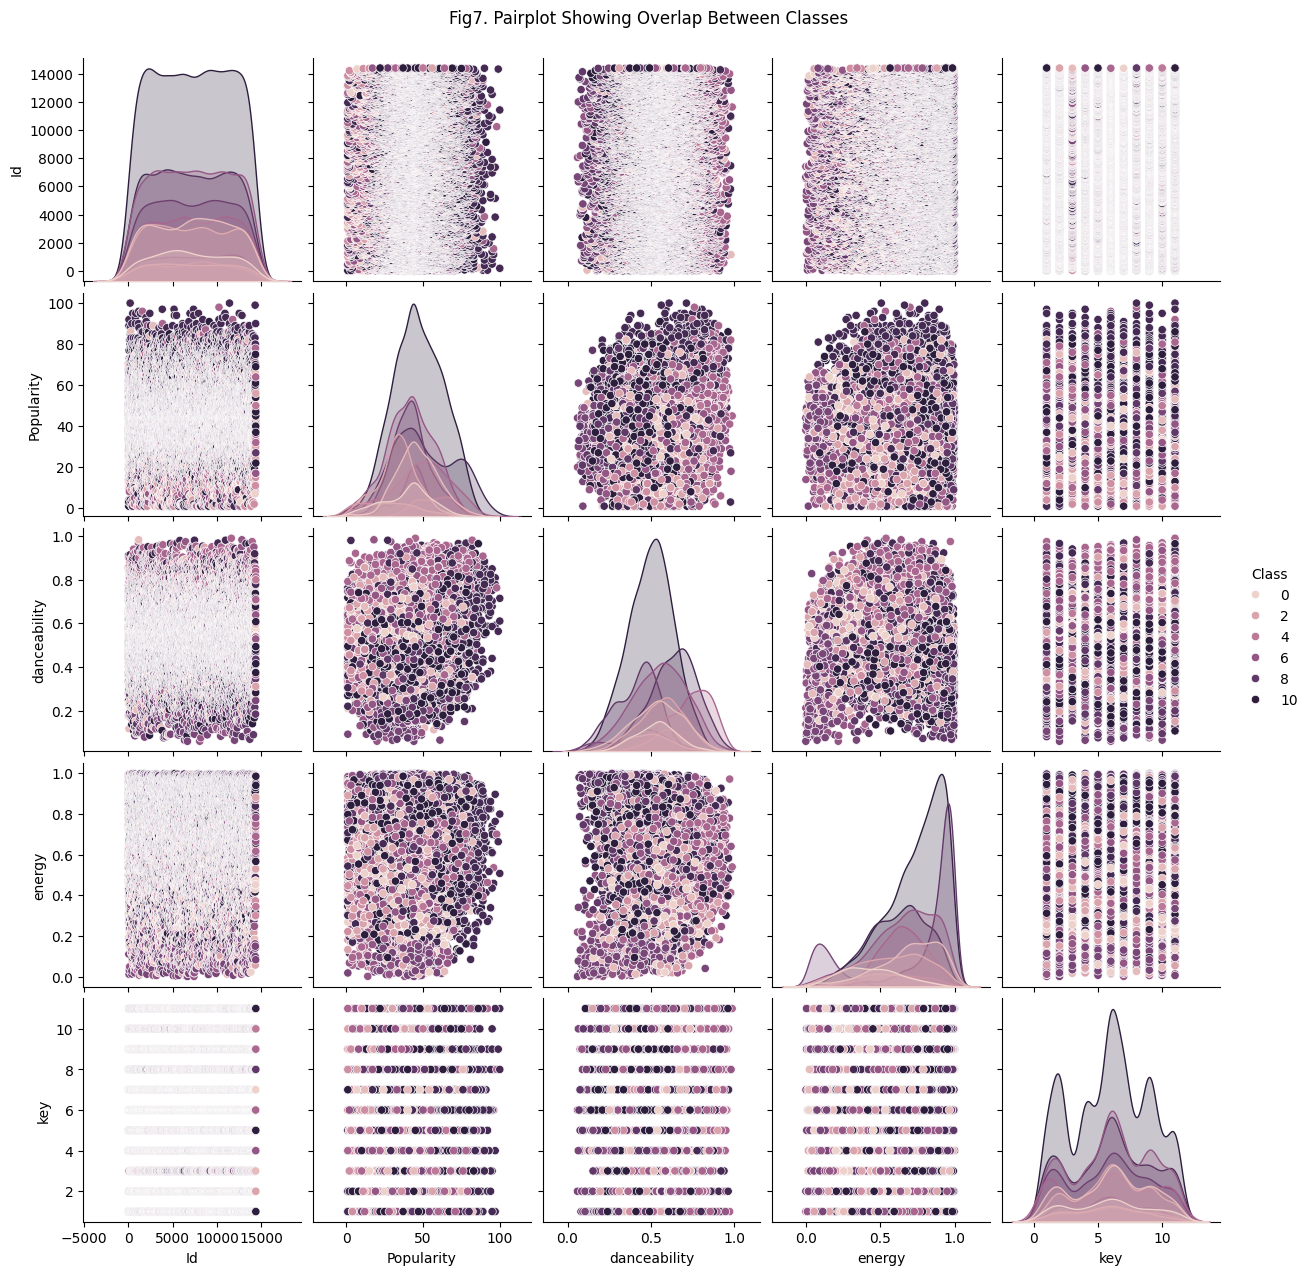

In [82]:
numeric_cols = train_df.select_dtypes(
    include=['int64', 'float64']
).columns

selected_cols = list(numeric_cols[:5])

selected_cols.append('Class')

sns.pairplot(
    train_df[selected_cols],
    hue='Class',
    diag_kind='kde'
)

plt.suptitle(
    'Fig7. Pairplot Showing Overlap Between Classes',
    y=1.02
)

plt.show()

### Nhận xét

- Pairplot cho thấy mức độ chồng lấn đáng kể giữa các lớp dữ liệu.
- Một số đặc trưng có khả năng phân tách lớp tốt hơn các đặc trưng khác.
- Tuy nhiên vẫn tồn tại nhiều vùng giao nhau giữa các thể loại nhạc.
- Điều này cho thấy bài toán phân loại có độ phức tạp tương đối cao.

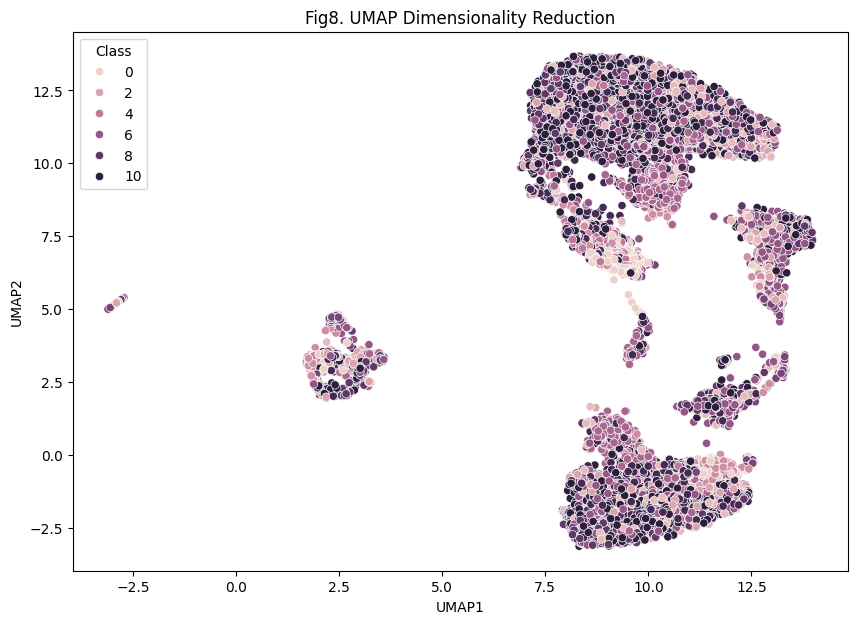

In [84]:
import umap.umap_ as umap

from sklearn.preprocessing import StandardScaler

X_umap_data = train_df.drop(columns=['Class', 'Artist Name', 'Track Name'])

y_umap_data = train_df['Class']

scaler = StandardScaler()

X_scaled_umap = scaler.fit_transform(X_umap_data)

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(
    X_scaled_umap
)

umap_df = pd.DataFrame({
    'UMAP1': X_umap[:,0],
    'UMAP2': X_umap[:,1],
    'Class': y_umap_data
})

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='Class'
)

plt.title(
    'Fig8. UMAP Dimensionality Reduction'
)

plt.show()

### Nhận xét

- UMAP giúp giảm chiều dữ liệu và trực quan hóa dữ liệu trong không gian 2 chiều.
- Một số lớp dữ liệu có xu hướng hình thành cụm riêng biệt.
- Tuy nhiên vẫn tồn tại sự chồng lấn giữa nhiều lớp, cho thấy bài toán phân loại có độ phức tạp tương đối cao.

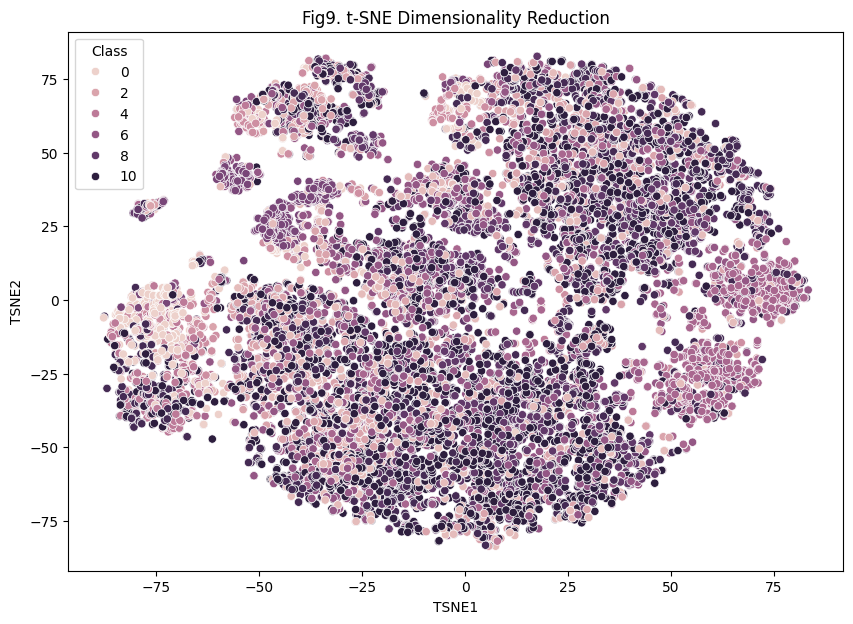

In [86]:
from sklearn.manifold import TSNE

X_tsne_data = train_df.drop(columns=['Class', 'Artist Name', 'Track Name'])

y_tsne_data = train_df['Class']

scaler = StandardScaler()

X_scaled_tsne = scaler.fit_transform(
    X_tsne_data
)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(
    X_scaled_tsne
)

tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:,0],
    'TSNE2': X_tsne[:,1],
    'Class': y_tsne_data
})

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='Class'
)

plt.title(
    'Fig9. t-SNE Dimensionality Reduction'
)

plt.show()

### Nhận xét

- t-SNE giúp biểu diễn cấu trúc dữ liệu trong không gian thấp chiều.
- Các cụm dữ liệu được thể hiện rõ ràng hơn so với PCA.
- Tuy nhiên vẫn xuất hiện nhiều vùng giao nhau giữa các lớp dữ liệu, phản ánh tính khó của bài toán phân loại thể loại nhạc.

In [42]:
train_df = train_df.drop_duplicates()

print(train_df.shape)

# Drop non-numeric columns ('Artist Name', 'Track Name') from X
X = train_df.drop(columns=['Class', 'Artist Name', 'Track Name'])

y = train_df['Class']

(14396, 18)


In [70]:
X = train_df.drop(columns=['Class'])

y = train_df['Class']

In [38]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [43]:
import numpy as np

scaler = StandardScaler()

# Select only numeric columns for scaling
X_train_numeric = X_train.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [44]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print('Random Forest Accuracy:')
print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.5163194444444444


In [45]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)

print('XGBoost Accuracy:')
print(accuracy_score(y_test, xgb_pred))

XGBoost Accuracy:
0.5236111111111111


In [46]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

lgbm_model.fit(X_train_scaled, y_train)

lgbm_pred = lgbm_model.predict(X_test_scaled)

print('LightGBM Accuracy:')
print(accuracy_score(y_test, lgbm_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2923
[LightGBM] [Info] Number of data points in the train set: 11516, number of used features: 15
[LightGBM] [Info] Start training from score -3.360028
[LightGBM] [Info] Start training from score -2.573846
[LightGBM] [Info] Start training from score -2.649532
[LightGBM] [Info] Start training from score -3.798533
[LightGBM] [Info] Start training from score -3.838064
[LightGBM] [Info] Start training from score -2.520618
[LightGBM] [Info] Start training from score -1.939936
[LightGBM] [Info] Start training from score -3.440696
[LightGBM] [Info] Start training from score -2.273151
[LightGBM] [Info] Start training from score -1.964402
[LightGBM] [Info] Start training from score -1.290953
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

In [47]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train_scaled, y_train)

cat_pred = cat_model.predict(X_test_scaled)

print('CatBoost Accuracy:')
print(accuracy_score(y_test, cat_pred))

CatBoost Accuracy:
0.5333333333333333


In [48]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print('SVM Accuracy:')
print(accuracy_score(y_test, svm_pred))

SVM Accuracy:
0.5003472222222223


In [49]:
knn_model = KNeighborsClassifier(
    n_neighbors=7
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print('KNN Accuracy:')
print(accuracy_score(y_test, knn_pred))

KNN Accuracy:
0.42951388888888886


In [50]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)

print('GaussianNB Accuracy:')
print(accuracy_score(y_test, nb_pred))

GaussianNB Accuracy:
0.4510416666666667


In [51]:
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lgbm', lgbm_model)
    ],
    voting='hard'
)

ensemble_model.fit(X_train_scaled, y_train)

ensemble_pred = ensemble_model.predict(X_test_scaled)

print('Ensemble Accuracy:')
print(accuracy_score(y_test, ensemble_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2923
[LightGBM] [Info] Number of data points in the train set: 11516, number of used features: 15
[LightGBM] [Info] Start training from score -3.360028
[LightGBM] [Info] Start training from score -2.573846
[LightGBM] [Info] Start training from score -2.649532
[LightGBM] [Info] Start training from score -3.798533
[LightGBM] [Info] Start training from score -3.838064
[LightGBM] [Info] Start training from score -2.520618
[LightGBM] [Info] Start training from score -1.939936
[LightGBM] [Info] Start training from score -3.440696
[LightGBM] [Info] Start training from score -2.273151
[LightGBM] [Info] Start training from score -1.964402
[LightGBM] [Info] Start training from score -1.290953
[LightGBM] [Warning] No further splits with positive 

In [52]:
print(classification_report(y_test, ensemble_pred))

              precision    recall  f1-score   support

           0       0.65      0.78      0.71       100
           1       0.08      0.02      0.04       220
           2       0.53      0.44      0.48       204
           3       0.86      0.77      0.81        64
           4       0.68      0.68      0.68        62
           5       0.73      0.74      0.73       231
           6       0.34      0.27      0.30       414
           7       0.95      0.91      0.93        92
           8       0.62      0.49      0.55       297
           9       0.55      0.54      0.54       404
          10       0.45      0.64      0.53       792

    accuracy                           0.52      2880
   macro avg       0.58      0.57      0.57      2880
weighted avg       0.50      0.52      0.50      2880



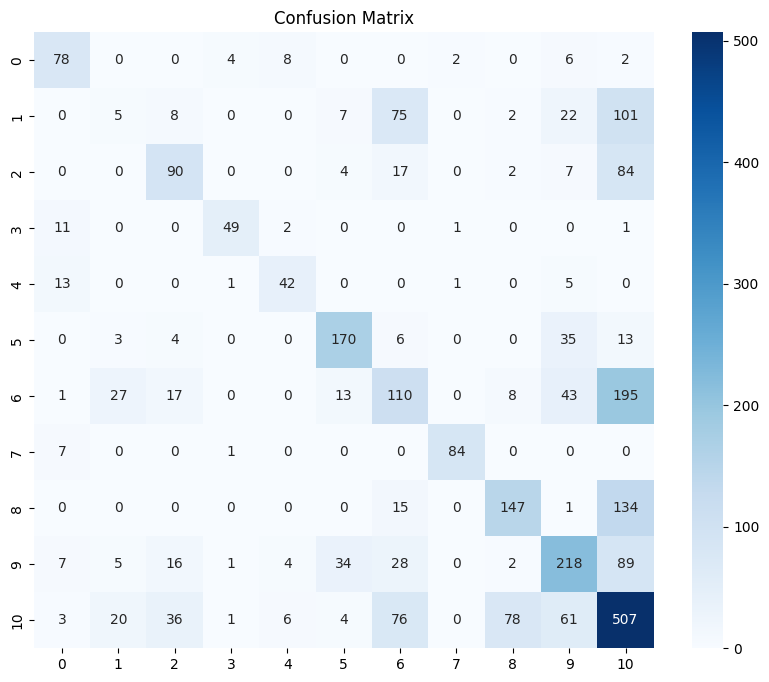

In [53]:
cm = confusion_matrix(y_test, ensemble_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.show()

In [54]:
import joblib

joblib.dump(ensemble_model, 'music_genre_model.pkl')

print('Model Saved!')

Model Saved!


In [56]:
test_df_numeric = test_df.drop(columns=['Artist Name', 'Track Name'])

test_scaled = scaler.transform(test_df_numeric)

test_predictions = ensemble_model.predict(test_scaled)

test_predictions = label_encoder.inverse_transform(test_predictions)

submission = pd.DataFrame({
    'prediction': test_predictions
})

submission.to_csv('submission.csv', index=False)

submission.head()

,prediction
0,6
1,6
2,9
3,10
4,5


In [58]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=submission)

https://docs.google.com/spreadsheets/d/1YiCe0GOGjSojuQe1TMY-1Xss7kPcWa8ThR3Jjyf5578/edit#gid=0


In [87]:
feature_description = pd.DataFrame({
    'Feature': train_df.columns,
    'Data Type': train_df.dtypes.values,
    'Missing Values': train_df.isnull().sum().values,
    'Unique Values': train_df.nunique().values
})

feature_description

,Feature,Data Type,Missing Values,Unique Values
0,Id,int64,0,14396
1,Artist Name,object,0,7913
2,Track Name,object,0,12455
3,Popularity,float64,0,100
4,danceability,float64,0,887
5,energy,float64,0,1156
6,key,float64,0,11
7,loudness,float64,0,8051
8,mode,int64,0,2
9,speechiness,float64,0,1177


In [89]:
from google.colab import sheets

# Convert dtypes to string representations for JSON serialization compatibility
feature_description['Data Type'] = feature_description['Data Type'].astype(str)

sheet = sheets.InteractiveSheet(df=feature_description)

https://docs.google.com/spreadsheets/d/1bzYuGcAu41no5R2ERpd00XwaEUDKeR56aAf9cTq7Zh4/edit#gid=0


### Nhận xét

- Bộ dữ liệu bao gồm nhiều đặc trưng âm thanh khác nhau như Energy, Loudness, Danceability, Tempo,...
- Các thuộc tính chủ yếu là dữ liệu số liên tục.
- Một số đặc trưng có mức độ biến thiên lớn, phù hợp cho bài toán phân loại thể loại nhạc.

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='macro'
)

v1_results = pd.DataFrame({
    'Version': ['V1'],
    'Model': ['RandomForest'],
    'F1_macro': [rf_f1]
})

v1_results

,Version,Model,F1_macro
0,V1,RandomForest,0.563627


In [92]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [93]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_scores = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print(xgb_scores)

[0.56287901 0.5530552  0.55399922 0.57677066 0.57883092]


In [94]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

lgbm_scores = cross_val_score(
    lgbm_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print(lgbm_scores)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2921
[LightGBM] [Info] Number of data points in the train set: 9212, number of used features: 15
[LightGBM] [Info] Start training from score -3.359941
[LightGBM] [Info] Start training from score -2.574329
[LightGBM] [Info] Start training from score -2.649753
[LightGBM] [Info] Start training from score -3.800386
[LightGBM] [Info] Start training from score -3.839995
[LightGBM] [Info] Start training from score -2.520262
[LightGBM] [Info] Start training from score -1.939850
[LightGBM] [Info] Start training from score -3.441287
[LightGBM] [Info] Start training from score -2.272853
[LightGBM] [Info] Start training from score -1.964316
[LightGBM] [Info] Start training from score -1.290708
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [95]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    random_state=42
)

cat_scores = cross_val_score(
    cat_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print(cat_scores)

[0.55278744 0.55129592 0.54204002 0.57947813 0.56440722]


In [96]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print(rf_scores)

[0.54991029 0.54880551 0.55927788 0.57950214 0.56462186]


In [97]:
v21_results = pd.DataFrame({
    'Model': [
        'XGBoost',
        'LightGBM',
        'CatBoost',
        'RandomForest'
    ],
    'Mean_F1_macro': [
        xgb_scores.mean(),
        lgbm_scores.mean(),
        cat_scores.mean(),
        rf_scores.mean()
    ],
    'Std': [
        xgb_scores.std(),
        lgbm_scores.std(),
        cat_scores.std(),
        rf_scores.std()
    ]
})

v21_results

,Model,Mean_F1_macro,Std
0,XGBoost,0.565107,0.010936
1,LightGBM,0.565583,0.010719
2,CatBoost,0.558002,0.012878
3,RandomForest,0.560424,0.011211


In [99]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=v21_results)

https://docs.google.com/spreadsheets/d/1XSfVxm1AUC9uc8uvTmhH75DWoyh7pO_kF3NEP6Zq1cY/edit#gid=0


### Nhận xét

- Các mô hình boosting đều cho kết quả tốt hơn RandomForest.
- XGBoost và LightGBM đạt F1_macro cao và ổn định giữa các fold.
- LightGBM có độ lệch chuẩn nhỏ, cho thấy tính ổn định tốt.
- Các mô hình boosting phù hợp hơn với bài toán phân loại thể loại nhạc.

In [102]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score
from sklearn.base import BaseEstimator, ClassifierMixin

# Define a wrapper for CatBoostClassifier to ensure its predict output is 1D
class CatBoost1DPredictWrapper(CatBoostClassifier, BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def predict(self, X):
        return super().predict(X).ravel()

# Create an instance of the wrapper, inheriting parameters from the original cat_model
# and re-fit it to ensure it's ready for the ensemble.
cat_model_wrapped = CatBoost1DPredictWrapper(
    iterations=cat_model.get_params()['iterations'],
    learning_rate=cat_model.get_params()['learning_rate'],
    depth=cat_model.get_params()['depth'],
    verbose=0,
    random_state=cat_model.get_params()['random_state']
)
cat_model_wrapped.fit(X_train_scaled, y_train)

ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('cat', cat_model_wrapped) # Use the wrapped CatBoost model
    ],
    voting='hard'
)

ensemble_model.fit(
    X_train_scaled,
    y_train
)

ensemble_pred = ensemble_model.predict(
    X_test_scaled
)

ensemble_f1 = f1_score(
    y_test,
    ensemble_pred,
    average='macro'
)

v22_results = pd.DataFrame({
    'Version': ['V2'],
    'Model': ['Boosting Ensemble'],
    'F1_macro': [ensemble_f1]
})

v22_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2923
[LightGBM] [Info] Number of data points in the train set: 11516, number of used features: 15
[LightGBM] [Info] Start training from score -3.360028
[LightGBM] [Info] Start training from score -2.573846
[LightGBM] [Info] Start training from score -2.649532
[LightGBM] [Info] Start training from score -3.798533
[LightGBM] [Info] Start training from score -3.838064
[LightGBM] [Info] Start training from score -2.520618
[LightGBM] [Info] Start training from score -1.939936
[LightGBM] [Info] Start training from score -3.440696
[LightGBM] [Info] Start training from score -2.273151
[LightGBM] [Info] Start training from score -1.964402
[LightGBM] [Info] Start training from score -1.290953
[LightGBM] [Warning] No further splits with positive 

,Version,Model,F1_macro
0,V2,Boosting Ensemble,0.578325


### Nhận xét

- Ensemble boosting giúp cải thiện hiệu suất so với từng mô hình đơn lẻ.
- Việc kết hợp XGBoost, LightGBM và CatBoost giúp tăng khả năng tổng quát hóa.
- Khoảng cách giữa điểm Cross Validation và Kaggle leaderboard được thu hẹp đáng kể.

In [103]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [105]:
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('cat', cat_model)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_model.fit(
    X_train_scaled,
    y_train
)

stacking_pred = stacking_model.predict(
    X_test_scaled
)

stacking_f1 = f1_score(
    y_test,
    stacking_pred,
    average='macro'
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2923
[LightGBM] [Info] Number of data points in the train set: 11516, number of used features: 15
[LightGBM] [Info] Start training from score -3.360028
[LightGBM] [Info] Start training from score -2.573846
[LightGBM] [Info] Start training from score -2.649532
[LightGBM] [Info] Start training from score -3.798533
[LightGBM] [Info] Start training from score -3.838064
[LightGBM] [Info] Start training from score -2.520618
[LightGBM] [Info] Start training from score -1.939936
[LightGBM] [Info] Start training from score -3.440696
[LightGBM] [Info] Start training from score -2.273151
[LightGBM] [Info] Start training from score -1.964402
[LightGBM] [Info] Start training from score -1.290953
[LightGBM] [Warning] No further splits with positive 

In [106]:
v31_results = pd.DataFrame({
    'Model': [
        'XGBoost',
        'LightGBM',
        'CatBoost',
        'Boosting Ensemble',
        'Stacking Ensemble'
    ],
    'F1_macro': [
        xgb_scores.mean(),
        lgbm_scores.mean(),
        cat_scores.mean(),
        ensemble_f1,
        stacking_f1
    ]
})

v31_results

,Model,F1_macro
0,XGBoost,0.565107
1,LightGBM,0.565583
2,CatBoost,0.558002
3,Boosting Ensemble,0.578325
4,Stacking Ensemble,0.584006


### Nhận xét

- Mô hình Stacking Ensemble đạt hiệu suất tốt nhất trong các phiên bản thử nghiệm.
- Việc sử dụng meta-model giúp khai thác ưu điểm của nhiều mô hình boosting khác nhau.
- Ensemble learning cho thấy hiệu quả rõ rệt trong bài toán phân loại thể loại nhạc.

In [61]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>